Пример на Python для «самой простой» модели:

случайная величина — урожайность Y с нормальной моделью,
фиксированные цена и затраты,
Monte Carlo по апостериору средней урожайности.

Упрощённый байес: сначала оценим μ и σ по данным классически,
а затем будем считать μ случайным с нормальным априором и апостериором
(normal–normal модель).

1. Исходные данные и «частотная» оценка

In [1]:
import numpy as np

rng = np.random.default_rng(42)

# Исторические урожайности (ц/га) - игрушечные данные
y_data = np.array([30, 32, 28, 35, 33, 31, 29, 34, 30, 32], dtype=float)

n = len(y_data)
y_mean = y_data.mean()
y_std = y_data.std(ddof=1)

print("n =", n)
print("Средняя урожайность =", y_mean)
print("Ст. отклонение =", y_std)

n = 10
Средняя урожайность = 31.4
Ст. отклонение = 2.2211108331943574


2. Простая байесовская модель для средней урожайности

Модель: $y_i \sim N(\mu, \sigma^{2})$, $\sigma$ считаем известной (берём оценку из данных), априор на $\mu$ — $N(\mu_0, \tau^{2})$.

In [2]:
# Априор на среднюю урожайность
mu0 = 30.0     # априорное ожидание
tau2 = 25.0    # априорная дисперсия (sigma_prior^2 = 5^2)

sigma2 = y_std**2  # считаем известной

# Параметры апостериора normal-normal
# mu | data ~ N(mu_n, tau2_n)

tau2_n = 1.0 / (1.0/tau2 + n / sigma2)
mu_n = tau2_n * (mu0/tau2 + n * y_mean / sigma2)

print("Апостериорное среднее mu_n =", mu_n)
print("Апостериорная дисперсия tau2_n =", tau2_n)
print("Апостериорное ст. откл. =", np.sqrt(tau2_n))


Апостериорное среднее mu_n = 31.372907949790797
Апостериорная дисперсия tau2_n = 0.48378661087866104
Апостериорное ст. откл. = 0.6955477056814011


3. Monte Carlo: выборки урожайности и прибыли

Возьмём фиксированные цену и затраты:

цена P=15000 руб/т,

затраты C=20000 руб/га,

площадь A=1000 га.

Урожайность в т/га = Y/10, если Y в ц/га.

In [3]:
# Параметры экономики
P = 15000.0   # руб/т
C = 20000.0   # руб/га
A = 1000.0    # га

n_sim = 10000

# 1) сэмплируем mu из апостериора
mu_samples = rng.normal(loc=mu_n, scale=np.sqrt(tau2_n), size=n_sim)

# 2) для каждого mu сэмплируем урожайность Y ~ N(mu, sigma^2)
Y_samples = rng.normal(loc=mu_samples, scale=np.sqrt(sigma2))

# 3) прибыль: Pi = P * (Y/10) * A - C * A
Pi_samples = P * (Y_samples / 10.0) * A - C * A

# Базовая статистика
pi_mean = Pi_samples.mean()
pi_median = np.median(Pi_samples)
prob_loss = np.mean(Pi_samples < 0)
var_5 = np.percentile(Pi_samples, 5)

pi_mean, pi_median, prob_loss, var_5


(np.float64(27116473.232214555),
 np.float64(27084408.27447465),
 np.float64(0.0),
 np.float64(21457919.164631862))

4. Вывод результатов

In [4]:
print(f"Средняя прибыль: {pi_mean:,.0f} руб.")
print(f"Медианная прибыль: {pi_median:,.0f} руб.")
print(f"Вероятность убытка: {prob_loss:.3f}")
print(f"5-й процентиль прибыли (VaR 5%): {var_5:,.0f} руб.")


Средняя прибыль: 27,116,473 руб.
Медианная прибыль: 27,084,408 руб.
Вероятность убытка: 0.000
5-й процентиль прибыли (VaR 5%): 21,457,919 руб.


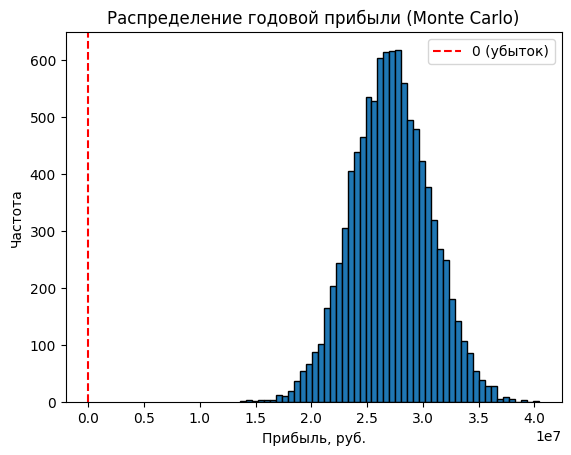

In [5]:
import matplotlib.pyplot as plt

plt.hist(Pi_samples, bins=50, edgecolor="k")
plt.axvline(0, color="red", linestyle="--", label="0 (убыток)")
plt.title("Распределение годовой прибыли (Monte Carlo)")
plt.xlabel("Прибыль, руб.")
plt.ylabel("Частота")
plt.legend()
plt.show()


Добавим случайную цену $P \sim N(\mu_P, \sigma_P)$, оставив всё остальное как есть. Меняется только блок имитации (шаг 3); оценку постериора $\mu_n, \tau_n^2$ и $\sigma^2$ оставляем прежней.

In [6]:
# Параметры экономики
A = 1000.0    # га

mu_P = 15000.0   # средняя цена, руб/т
sd_P = 3000.0    # ст. отклонение цены

C = 20000.0      # затраты, руб/га (фикcированы)

n_sim = 10000

# 1) сэмплируем mu из апостериора
mu_samples = rng.normal(loc=mu_n, scale=np.sqrt(tau2_n), size=n_sim)

# 2) урожайность Y ~ N(mu, sigma^2)
Y_samples = rng.normal(loc=mu_samples, scale=np.sqrt(sigma2))

# 3) цена P ~ N(mu_P, sd_P^2)
P_samples = rng.normal(loc=mu_P, scale=sd_P, size=n_sim)

# 4) прибыль: Pi = P * (Y/10) * A - C * A
Pi_samples = P_samples * (Y_samples / 10.0) * A - C * A

# Базовая статистика
pi_mean = Pi_samples.mean()
pi_median = np.median(Pi_samples)
prob_loss = np.mean(Pi_samples < 0)
var_5 = np.percentile(Pi_samples, 5)

print(f"Средняя прибыль: {pi_mean:,.0f} руб.")
print(f"Медианная прибыль: {pi_median:,.0f} руб.")
print(f"Вероятность убытка: {prob_loss:.3f}")
print(f"5-й процентиль прибыли (VaR 5%): {var_5:,.0f} руб.")


Средняя прибыль: 26,857,683 руб.
Медианная прибыль: 26,628,318 руб.
Вероятность убытка: 0.003
5-й процентиль прибыли (VaR 5%): 11,038,995 руб.


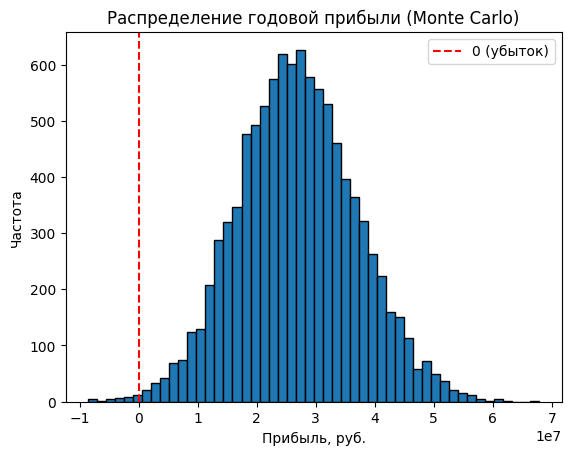

In [7]:
import matplotlib.pyplot as plt

plt.hist(Pi_samples, bins=50, edgecolor="k")
plt.axvline(0, color="red", linestyle="--", label="0 (убыток)")
plt.title("Распределение годовой прибыли (Monte Carlo)")
plt.xlabel("Прибыль, руб.")
plt.ylabel("Частота")
plt.legend()
plt.show()